# Imports

In [5]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import sys
sys.path.append('/home/buka2004/DRMNet/')
import torch
from utils.file_io import load_exr, load_png, save_png
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Utils

In [5]:
def plot_exr(exr_path):
  input_img = load_exr(exr_path, as_torch=True)
  img = np.array(input_img)

  # Method 1: Basic plot (tonemapped for visibility)
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 3, 1)
  plt.imshow(img)
  plt.title(f'Raw EXR (max: {img.max():.2f}, min: {img.min():.2f})')
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(img.clip(0, 1))  # Clip to [0,1] range
  plt.title('Clipped [0,1]')
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow((img - img.min()) / (img.max() - img.min()))  # Normalize to [0,1]
  plt.title('Normalized [0,1]')
  plt.axis('off')

  plt.tight_layout()
  plt.show()


# Data analisys

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0028419495..2108.0].


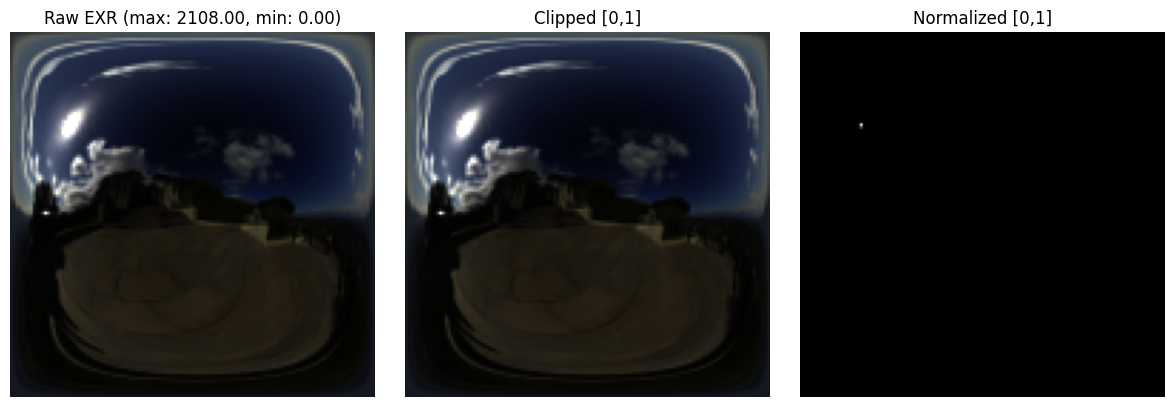

In [11]:
plot_exr('/home/buka2004/DRMNet/.data/drmnet_synth_test/rhodes_memorial/r0.exr')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007049343..1243.3453].


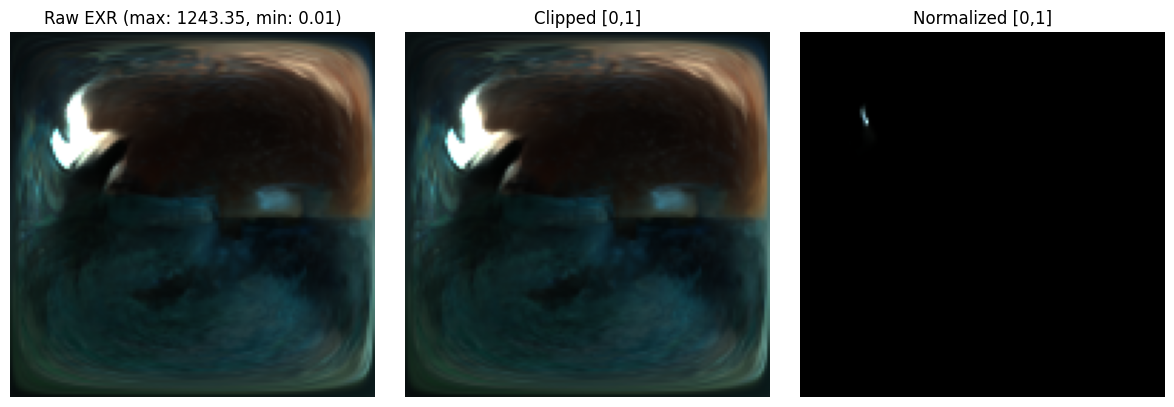

In [10]:
plot_exr('/home/buka2004/DRMNet/validation_outputs/preds/rhodes_memorial_r0.exr')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009552002..8.8828125].


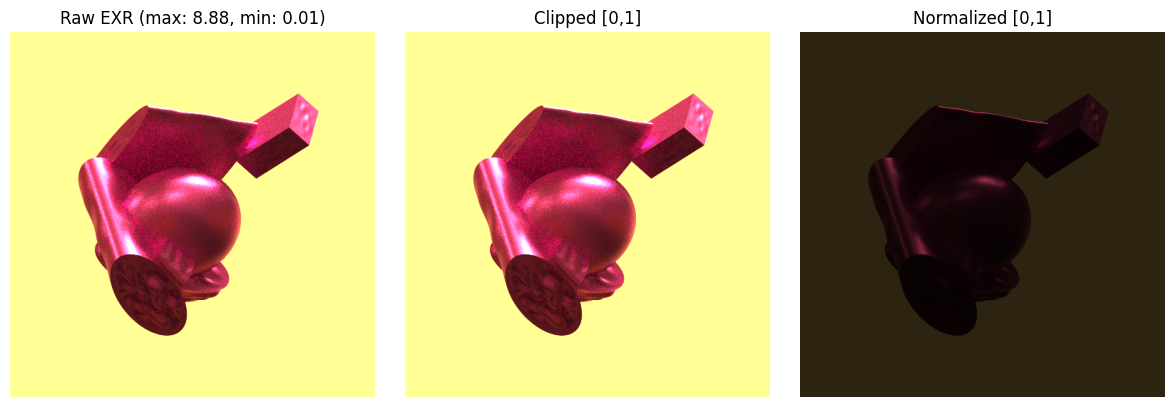

In [24]:
plot_exr('/home/buka2004/DRMNet/.data/drmnet_synth_test/9C4A0022-6d8fe2e88e/obj.exr')

/tmp/ipykernel_255448/1424859290.py:19: RuntimeWarning: invalid value encountered in divide
  plt.imshow((img - img.min()) / (img.max() - img.min()))  # Normalize to [0,1]


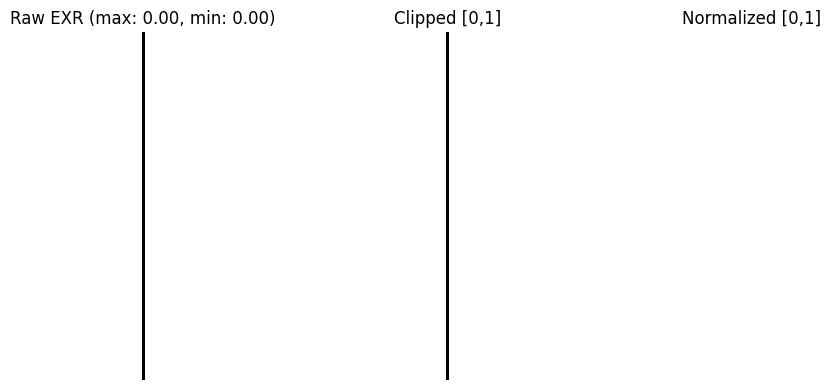

In [25]:
plot_exr('/home/buka2004/DRMNet/.data/drmnet_synth_test/9C4A0022-6d8fe2e88e/depth.exr')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..81.5625].


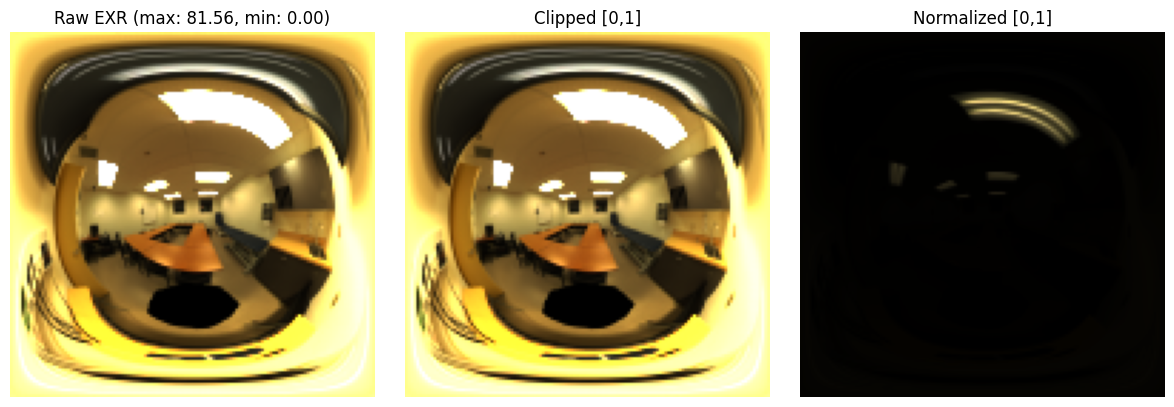

In [27]:
plot_exr('/home/buka2004/DRMNet/.data/drmnet_synth_test/9C4A0022-6d8fe2e88e/r0.exr')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057678223..11.6875].


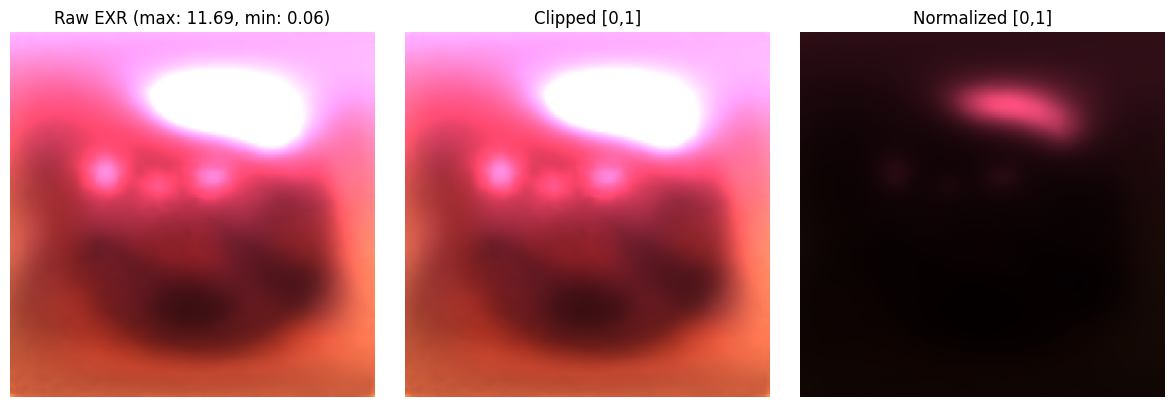

In [29]:
plot_exr('/home/buka2004/DRMNet/.data/drmnet_synth_test/9C4A0022-6d8fe2e88e/rK.exr')

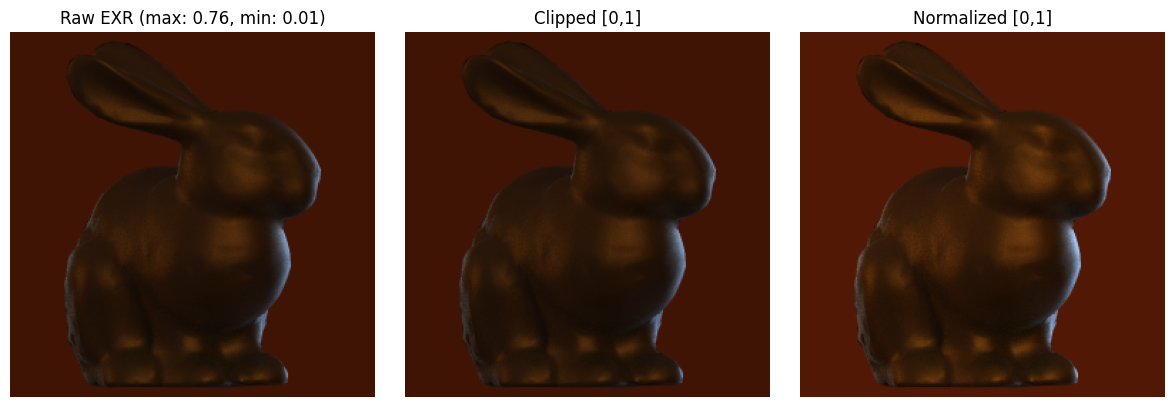

In [31]:
plot_exr('/home/buka2004/DRMNet/.data/data/sample/image.exr')

# Result analisys

In [8]:
csv_path = '/home/buka2004/DRMNet/validation_outputs/validation_results.csv'

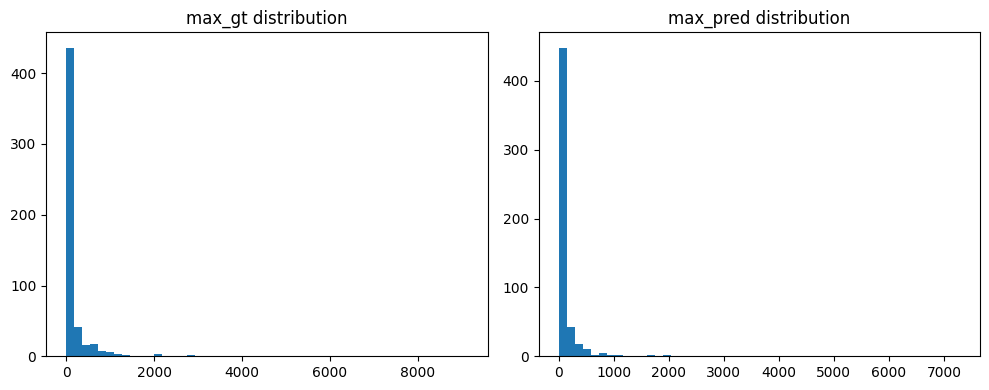

In [9]:
df = pd.read_csv(csv_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["max_gt"], bins=50)
axes[0].set_title("max_gt distribution")

axes[1].hist(df["max_pred"], bins=50)
axes[1].set_title("max_pred distribution")

plt.tight_layout()
plt.show()
